In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [5]:
multithread_df = pd.read_csv("multithread_results.csv")
multithread_df.head()

,Type,Size,Threads,ComputationTimeMs,ExecutionTimeMs,DataTransferTimeMs,Throughput,Speedup,Sorted
0,Multithread,10000,1,173.936,173.936,0.0,57492.48,1.00,Yes
1,Multithread,10000,2,491.160,491.160,0.0,20359.95,0.35,Yes
2,Multithread,10000,4,543.586,543.586,0.0,18396.35,0.32,Yes
3,Multithread,10000,8,572.193,572.193,0.0,17476.62,0.30,Yes
4,Multithread,10000,16,771.355,771.355,0.0,12964.21,0.23,Yes


In [7]:
mean_df = (
    multithread_df.groupby(["Type", "Size", "Threads"], as_index=False)
      .agg(
          ComputationTimeMs_mean=("ComputationTimeMs", "mean"),
          ExecutionTimeMs_mean=("ExecutionTimeMs", "mean"),
          DataTransferTimeMs_mean=("DataTransferTimeMs", "mean"),
          Throughput_mean=("Throughput", "mean"),
          Speedup_mean=("Speedup", "mean"),
          Sorted=("Sorted", "first")
      )
)

mean_df

,Type,Size,Threads,ComputationTimeMs_mean,ExecutionTimeMs_mean,DataTransferTimeMs_mean,Throughput_mean,Speedup_mean,Sorted
0,Multithread,10000,1,173.936,173.936,0.0,57492.48,1.00,Yes
1,Multithread,10000,2,491.160,491.160,0.0,20359.95,0.35,Yes
2,Multithread,10000,4,543.586,543.586,0.0,18396.35,0.32,Yes
3,Multithread,10000,8,572.193,572.193,0.0,17476.62,0.30,Yes
4,Multithread,10000,16,771.355,771.355,0.0,12964.21,0.23,Yes
5,Multithread,100000,1,20608.966,20608.966,0.0,4852.26,1.00,Yes
6,Multithread,100000,2,51920.715,51920.715,0.0,1926.01,0.40,Yes
7,Multithread,100000,4,67368.503,67368.503,0.0,1484.37,0.31,Yes
8,Multithread,100000,8,75577.001,75577.001,0.0,1323.15,0.27,Yes
9,Multithread,100000,16,74907.139,74907.139,0.0,1334.99,0.28,Yes


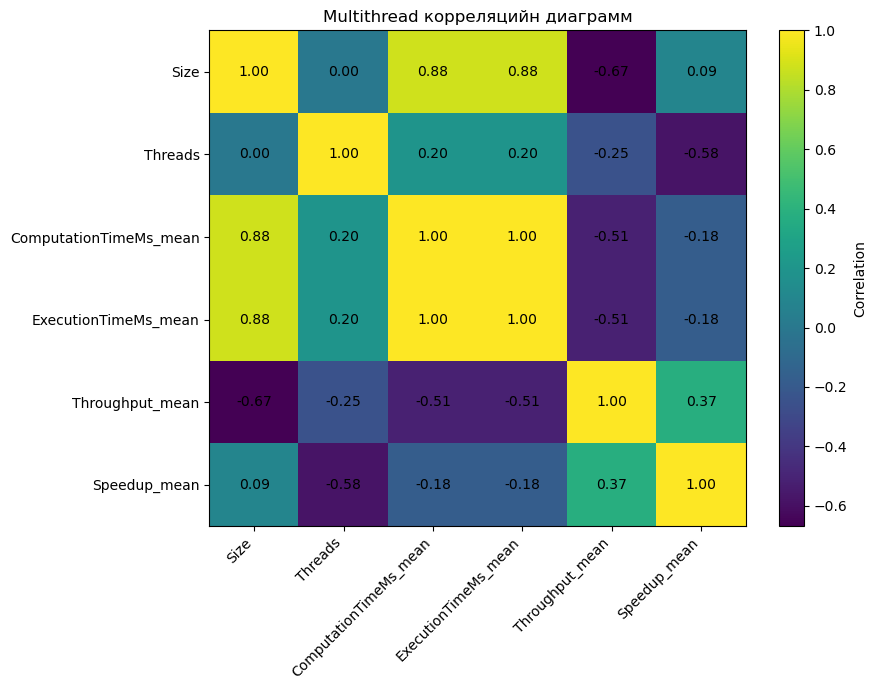

In [11]:
numeric_df = mean_df[
    [
        "Size",
        "Threads",
        "ComputationTimeMs_mean",
        "ExecutionTimeMs_mean",
        "DataTransferTimeMs_mean",
        "Throughput_mean",
        "Speedup_mean"
    ]
]

numeric_df = numeric_df.loc[:, numeric_df.nunique() > 1]

corr_df = numeric_df.corr()

plt.figure(figsize=(9, 7))

plt.imshow(corr_df, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr_df.columns)),
    corr_df.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr_df.columns)),
    corr_df.columns
)

for i in range(len(corr_df.columns)):
    for j in range(len(corr_df.columns)):
        plt.text(
            j,
            i,
            f"{corr_df.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Multithread корреляцийн диаграмм")
plt.tight_layout()
plt.savefig("../images/multithread_correlation_diagram.png", dpi=600, bbox_inches="tight")
plt.show()

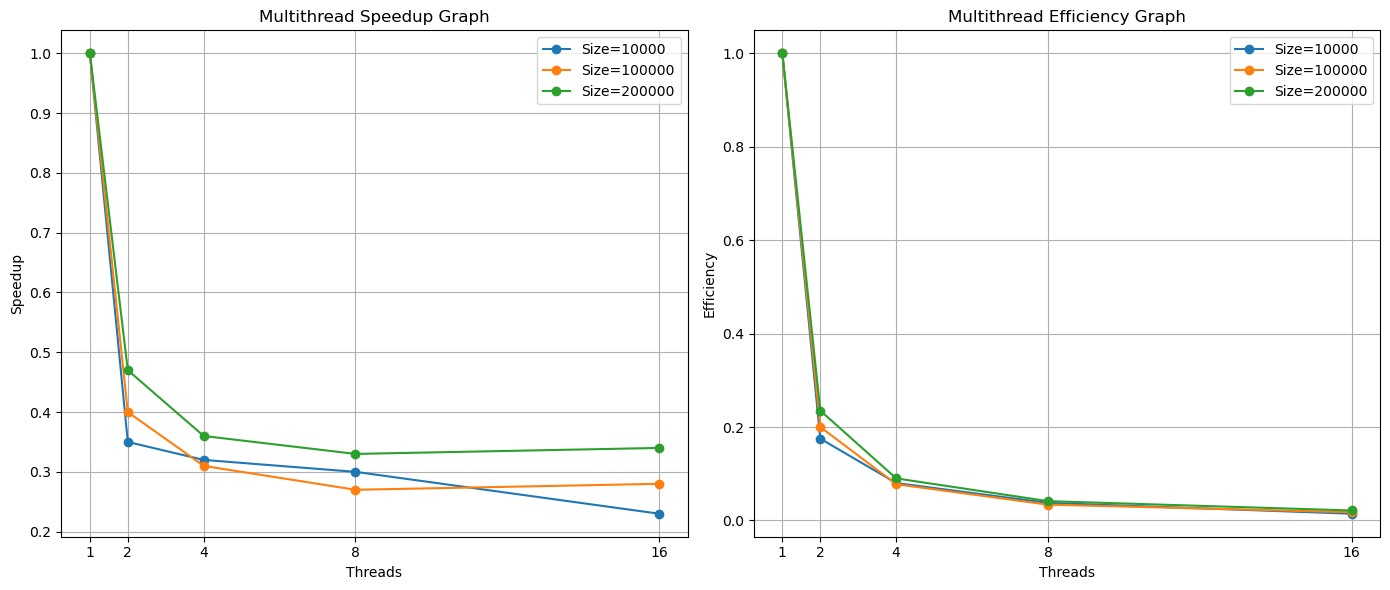

In [26]:
mean_df["Efficiency_mean"] = mean_df["Speedup_mean"] / mean_df["Threads"]

sizes = sorted(mean_df["Size"].unique())

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -----------------------------
# Subplot 1: Speedup
# -----------------------------
for size in sizes:
    subset = mean_df[mean_df["Size"] == size].sort_values("Threads")
    axes[0].plot(
        subset["Threads"],
        subset["Speedup_mean"],
        marker='o',
        label=f"Size={size}"
    )

axes[0].set_title("Multithread Speedup Graph")
axes[0].set_xlabel("Threads")
axes[0].set_ylabel("Speedup")
axes[0].set_xticks(sorted(mean_df["Threads"].unique()))
axes[0].grid(True)
axes[0].legend()

# -----------------------------
# Subplot 2: Efficiency
# -----------------------------
for size in sizes:
    subset = mean_df[mean_df["Size"] == size].sort_values("Threads")
    axes[1].plot(
        subset["Threads"],
        subset["Efficiency_mean"],
        marker='o',
        label=f"Size={size}"
    )

axes[1].set_title("Multithread Efficiency Graph")
axes[1].set_xlabel("Threads")
axes[1].set_ylabel("Efficiency")
axes[1].set_xticks(sorted(mean_df["Threads"].unique()))
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.savefig("../images/multithread_speedup_efficiency_subplot.png", dpi=300, bbox_inches="tight")
plt.show()